# GT Vessel Pixel Count Distribution -- Dataset502_ARCADE_6x6_1c

`Dataset502_ARCADE_6x6_1c` is the binary vessel/background patch dataset used
to train `SmallENet` (see `train_small_enet_6x6_1c.job`): each raw ARCADE frame
is split into a `6x6` grid of patches, and every patch's `labelsTr` mask is
binary (`0` = background, `1` = vessel).

This notebook computes, for every one of the 73,200 GT patch masks, the total
count of positive (vessel) pixels -- i.e. how many pixels in that mask are `1`
-- and plots the distribution of that count across the dataset as a histogram.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


def _find_repo_root(start: Path) -> Path:
    """Walk up from cwd looking for the repo root, so this notebook works the
    same whether Jupyter's cwd is the repo root or analysis/dataset itself."""
    for candidate in [start, *start.parents]:
        if (candidate / "lightm-unet").exists() and (candidate / "data").exists():
            return candidate
    return start


REPO_ROOT = _find_repo_root(Path.cwd())
DATASET_NAME = "Dataset502_ARCADE_6x6_1c"
DATASET_DIR = REPO_ROOT / "data" / "nnUNet_raw" / DATASET_NAME
LABELS_TR_DIR = DATASET_DIR / "labelsTr"
METRICS_DIR = REPO_ROOT / "analysis" / "dataset" / "results"
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root   :", REPO_ROOT)
print("Dataset dir :", DATASET_DIR)
print("LabelsTr    :", LABELS_TR_DIR)

Repo root   : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet
Dataset dir : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\data\nnUNet_raw\Dataset502_ARCADE_6x6_1c
LabelsTr    : C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\data\nnUNet_raw\Dataset502_ARCADE_6x6_1c\labelsTr


## Build the file index

Patch filenames follow `train_<case>_<p|b><patch_idx>.png`. The `p`/`b` prefix
marks which half of the sampling strategy a patch came from (positive-region vs.
background-region seeding) -- it is a pre-label sampling choice, not the actual
vessel content of the patch, so it's tracked here for reference but the pixel
counts below are what actually matter.

In [2]:
FNAME_RE = re.compile(r"^(?P<case>.+)_(?P<kind>[pb])(?P<patch_idx>\d+)$")

label_files = sorted(LABELS_TR_DIR.glob("*.png"))
print(f"Found {len(label_files)} label masks")
assert label_files, f"No label masks found in {LABELS_TR_DIR}"

Found 73200 label masks


## Compute total vessel-positive pixel count per mask

Each mask is binary (`{0, 1}`), so the "total TP" (total positive / vessel
pixels) per mask is just `mask.sum()`.

In [3]:
records = []
for path in label_files:
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    vessel_px = int((arr == 1).sum())
    total_px = int(arr.size)
    m = FNAME_RE.match(path.stem)
    kind = m.group("kind") if m else "?"
    records.append({
        "file": path.name,
        "kind": kind,
        "vessel_px": vessel_px,
        "total_px": total_px,
        "vessel_frac": vessel_px / total_px,
    })

df = pd.DataFrame.from_records(records)
df.to_csv(METRICS_DIR / f"{DATASET_NAME}_gt_vessel_pixel_counts.csv", index=False)
print(f"Saved per-mask counts to {METRICS_DIR / f'{DATASET_NAME}_gt_vessel_pixel_counts.csv'}")
df.head()

Saved per-mask counts to C:\Users\win32\Desktop\University\Thesis\repos\LightM-UNet\analysis\dataset\results\Dataset502_ARCADE_6x6_1c_gt_vessel_pixel_counts.csv


,file,kind,vessel_px,total_px,vessel_frac
0,train_1000_b0000.png,b,0,7225,0.000000
1,train_1000_b0001.png,b,163,7225,0.022561
2,train_1000_b0002.png,b,1140,7225,0.157785
3,train_1000_b0003.png,b,0,7225,0.000000
4,train_1000_b0004.png,b,0,7225,0.000000


## Summary statistics

In [4]:
summary = df["vessel_px"].describe()
n_empty = int((df["vessel_px"] == 0).sum())
print(f"Masks with zero vessel pixels: {n_empty} / {len(df)} ({n_empty / len(df):.1%})")
print()
print(summary)

by_kind = df.groupby("kind")["vessel_px"].describe()
print()
print("By filename kind (p=positive-seeded, b=background-seeded):")
by_kind

Masks with zero vessel pixels: 45244 / 73200 (61.8%)

count    73200.000000
mean       279.667637
std        497.315423
min          0.000000
25%          0.000000
50%          0.000000
75%        404.000000
max       4170.000000
Name: vessel_px, dtype: float64

By filename kind (p=positive-seeded, b=background-seeded):


,count,mean,std,min,25%,50%,75%,max
kind,,,,,,,,
b,30000.0,334.170267,526.604479,0.0,0.0,0.0,584.0,3531.0
p,43200.0,241.818588,472.236084,0.0,0.0,0.0,251.0,4170.0


## Histogram: distribution of total vessel pixels per mask

Bulk of the mass sits near zero (background-seeded and empty-vessel patches),
with a long right tail for patches that are mostly vessel -- so this is shown
both on a linear count axis and a log-scaled y-axis to make the tail legible.

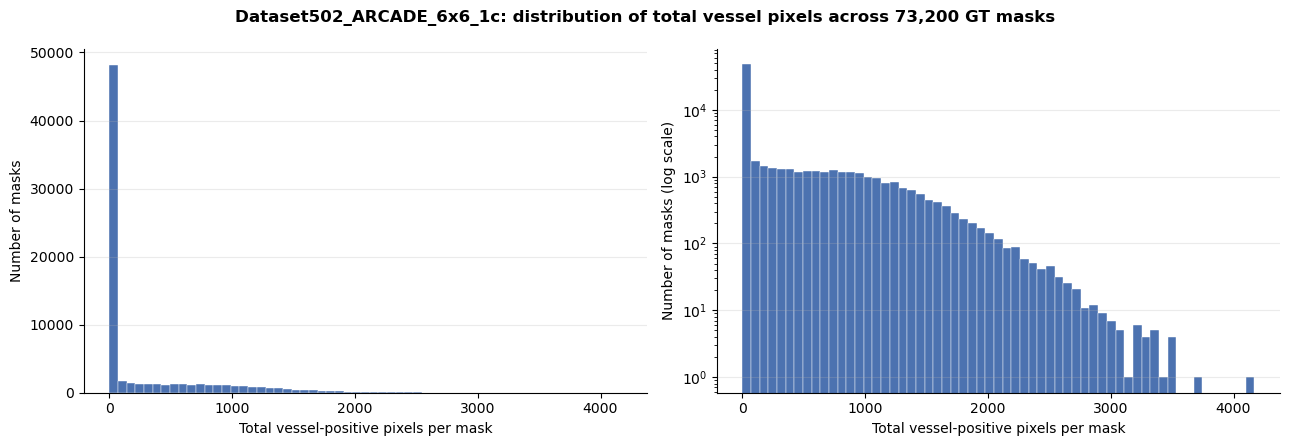

In [5]:
COLOR = "#4C72B0"  # single series -> one hue, no categorical palette needed

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.linspace(0, df["vessel_px"].max(), 60)

for ax, log_y in zip(axes, [False, True]):
    ax.hist(df["vessel_px"], bins=bins, color=COLOR, edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Total vessel-positive pixels per mask")
    ax.set_ylabel("Number of masks" + (" (log scale)" if log_y else ""))
    if log_y:
        ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(f"{DATASET_NAME}: distribution of total vessel pixels across {len(df):,} GT masks", fontweight="bold")
plt.tight_layout()
fig.savefig(METRICS_DIR / f"{DATASET_NAME}_gt_vessel_pixel_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

## Histogram: vessel pixel fraction per mask

Same distribution normalized by patch size (`vessel_px / total_px`), useful
since a handful of edge patches are cropped smaller than the rest.

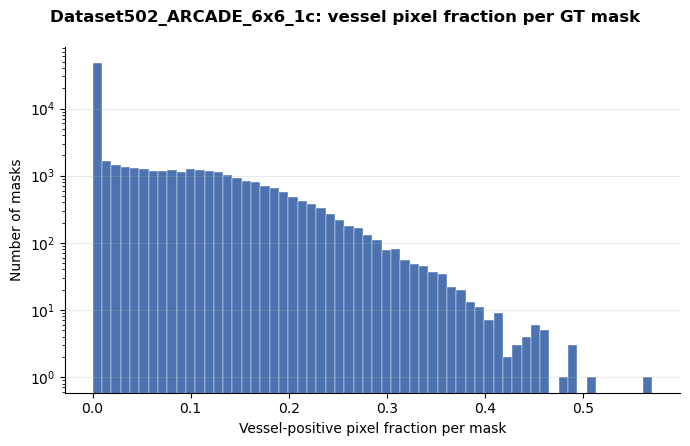

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["vessel_frac"], bins=60, color=COLOR, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Vessel-positive pixel fraction per mask")
ax.set_ylabel("Number of masks")
ax.set_yscale("log")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)
fig.suptitle(f"{DATASET_NAME}: vessel pixel fraction per GT mask", fontweight="bold")
plt.tight_layout()
fig.savefig(METRICS_DIR / f"{DATASET_NAME}_gt_vessel_fraction_histogram.png", dpi=150, bbox_inches="tight")
plt.show()